## Import dependencies

In [ ]:
# Selecting Tensorflow version v2 (the command is relevant for Colab only).
# %tensorflow_version 2.x

In [2]:
pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 72.1 MB/s eta 0:00:00


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import platform
import time
import pathlib
import os
from spellchecker import SpellChecker

print('Python version:', platform.python_version())
print('Tensorflow version:', tf.__version__)
print('Keras version:', tf.keras.__version__)

Python version: 3.11.12
Tensorflow version: 2.18.0
Keras version: 3.8.0


## Download the dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')
dataset_file_path = '/content/drive/MyDrive/Colab Notebooks/sherlockholmes.txt'

cache_dir = './tmp'
dataset_file_name = 'sherlockholmes.txt'


print(dataset_file_path)

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/sherlockholmes.txt


In [5]:
# Load the text
with open(dataset_file_path, 'r') as file:
    text = file.read()

print(f"Loaded {len(text)} characters.")

Loaded 580217 characters.


## Analyze the dataset

In [6]:
# Take a look at the first 250 characters in text.
print(text[:250])

The Adventures of Sherlock Holmes

by Arthur Conan Doyle

I. A SCANDAL IN BOHEMIA


I.

To Sherlock Holmes she is always _the_ woman. I have seldom heard him
mention her under any other name. In his eyes she eclipses and
predominates the whole of her


In [7]:
# The unique characters in the file
vocab = sorted(set(text))

print('{} unique characters'.format(len(vocab)))
print('vocab:', vocab)

94 unique characters
vocab: ['\n', ' ', '!', '$', '%', '&', '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '£', '½', 'à', 'â', 'æ', 'è', 'é', 'œ', '—', '‘', '’', '“', '”', '•', '™']


## Process the dataset

### Vectorize the text

Before feeding the text to our RNN we need to convert the text from a sequence of characters to a sequence of numbers. To do so we will detect all unique characters in the text, form a vocabulary out of it and replace each character with its index in the vocabulary.

In [8]:
# Map characters to their indices in vocabulary.
char2index = {char: index for index, char in enumerate(vocab)}

print('{')
for char, _ in zip(char2index, range(20)):
    print('  {:4s}: {:3d},'.format(repr(char), char2index[char]))
print('  ...\n}')

{
  '\n':   0,
  ' ' :   1,
  '!' :   2,
  '$' :   3,
  '%' :   4,
  '&' :   5,
  '(' :   6,
  ')' :   7,
  '*' :   8,
  ',' :   9,
  '-' :  10,
  '.' :  11,
  '/' :  12,
  '0' :  13,
  '1' :  14,
  '2' :  15,
  '3' :  16,
  '4' :  17,
  '5' :  18,
  '6' :  19,
  ...
}


In [9]:
# Map character indices to characters from vacabulary.
index2char = np.array(vocab)
print(index2char)

['\n' ' ' '!' '$' '%' '&' '(' ')' '*' ',' '-' '.' '/' '0' '1' '2' '3' '4'
 '5' '6' '7' '8' '9' ':' ';' '?' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J'
 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' '_' 'a'
 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r' 's'
 't' 'u' 'v' 'w' 'x' 'y' 'z' '£' '½' 'à' 'â' 'æ' 'è' 'é' 'œ' '—' '‘' '’'
 '“' '”' '•' '™']


In [10]:
# Convert chars in text to indices.
text_as_int = np.array([char2index[char] for char in text])

print('text_as_int length: {}'.format(len(text_as_int)))
print('{} --> {}'.format(repr(text[:15]), repr(text_as_int[:15])))

text_as_int length: 580217
'The Adventures ' --> array([45, 60, 57,  1, 26, 56, 74, 57, 66, 72, 73, 70, 57, 71,  1])


## Create training sequences

In [11]:
# The maximum length sentence we want for a single input in characters.
sequence_length = 100
examples_per_epoch = len(text) // (sequence_length + 1)

print('examples_per_epoch:', examples_per_epoch)

examples_per_epoch: 5744


In [12]:
# Create training dataset.
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

for char in char_dataset.take(5):
    print(index2char[char.numpy()])

T
h
e
 
A


In [13]:
# Generate batched sequences out of the char_dataset.
sequences = char_dataset.batch(sequence_length + 1, drop_remainder=True)

# Sequences size is the same as examples_per_epoch.
print('Sequences count: {}'.format(len(list(sequences.as_numpy_iterator()))));
print()

# Sequences examples.
for item in sequences.take(5):
    print(repr(''.join(index2char[item.numpy()])))

Sequences count: 5744

'The Adventures of Sherlock Holmes\n\nby Arthur Conan Doyle\n\nI. A SCANDAL IN BOHEMIA\n\n\nI.\n\nTo Sherlock H'
'olmes she is always _the_ woman. I have seldom heard him\nmention her under any other name. In his eye'
's she eclipses and\npredominates the whole of her sex. It was not that he felt any emotion\nakin to lov'
'e for Irene Adler. All emotions, and that one particularly,\nwere abhorrent to his cold, precise but a'
'dmirably balanced mind. He\nwas, I take it, the most perfect reasoning and observing machine that\nthe '


In [14]:
# sequences shape:
# - 11043 sequences
# - Each sequence of length 101
#
#
#    101     101          101
# [(.....) (.....) ...  (.....)]
#
# <---------- 11043 ----------->

For each sequence, duplicate and shift it to form the input and target text. For example, say `sequence_length` is `4` and our text is `Hello`. The input sequence would be `Hell`, and the target sequence `ello`.

In [15]:
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

In [16]:
dataset = sequences.map(split_input_target)

# Dataset size is the same as examples_per_epoch.
# But each element of a sequence is now has length of `sequence_length`
# and not `sequence_length + 1`.
print('dataset size: {}'.format(len(list(dataset.as_numpy_iterator()))))

dataset size: 5744


In [17]:
for input_example, target_example in dataset.take(1):
    print('Input sequence size:', repr(len(input_example.numpy())))
    print('Target sequence size:', repr(len(target_example.numpy())))
    print()
    print('Input:', repr(''.join(index2char[input_example.numpy()])))
    print('Target:', repr(''.join(index2char[target_example.numpy()])))

Input sequence size: 100
Target sequence size: 100

Input: 'The Adventures of Sherlock Holmes\n\nby Arthur Conan Doyle\n\nI. A SCANDAL IN BOHEMIA\n\n\nI.\n\nTo Sherlock '
Target: 'he Adventures of Sherlock Holmes\n\nby Arthur Conan Doyle\n\nI. A SCANDAL IN BOHEMIA\n\n\nI.\n\nTo Sherlock H'


In [18]:
# dataset shape:
# - 11043 sequences
# - Each sequence is a tuple of 2 sub-sequences of length 100 (input_text and target_text)
#
#
#    100       100           100
# /(.....)\ /(.....)\ ... /(.....)\  <-- input_text
# \(.....)/ \(.....)/     \(.....)/  <-- target_text
#
# <----------- 11043 ------------->

Each index of these vectors are processed as one time step. For the input at time step 0, the model receives the index for "F" and trys to predict the index for "i" as the next character. At the next timestep, it does the same thing but the RNN considers the previous step context in addition to the current input character.

In [19]:
for i, (input_idx, target_idx) in enumerate(zip(input_example[:5], target_example[:5])):
    print('Step {:2d}'.format(i))
    print('  input: {} ({:s})'.format(input_idx, repr(index2char[input_idx])))
    print('  expected output: {} ({:s})'.format(target_idx, repr(index2char[target_idx])))

Step  0
  input: 45 (np.str_('T'))
  expected output: 60 (np.str_('h'))
Step  1
  input: 60 (np.str_('h'))
  expected output: 57 (np.str_('e'))
Step  2
  input: 57 (np.str_('e'))
  expected output: 1 (np.str_(' '))
Step  3
  input: 1 (np.str_(' '))
  expected output: 26 (np.str_('A'))
Step  4
  input: 26 (np.str_('A'))
  expected output: 56 (np.str_('d'))


## Split training sequences into batches

We used `tf.data` to split the text into manageable sequences. But before feeding this data into the model, we need to shuffle the data and pack it into batches.

In [20]:
# Batch size.
BATCH_SIZE = 64

# Buffer size to shuffle the dataset (TF data is designed to work
# with possibly infinite sequences, so it doesn't attempt to shuffle
# the entire sequence in memory. Instead, it maintains a buffer in
# which it shuffles elements).
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

dataset

<_BatchDataset element_spec=(TensorSpec(shape=(64, 100), dtype=tf.int64, name=None), TensorSpec(shape=(64, 100), dtype=tf.int64, name=None))>

In [21]:
print('Batched dataset size: {}'.format(len(list(dataset.as_numpy_iterator()))))

Batched dataset size: 89


In [22]:
for input_text, target_text in dataset.take(1):
    print('1st batch: input_text:', input_text)
    print()
    print('1st batch: target_text:', target_text)

1st batch: input_text: tf.Tensor(
[[67 55 63 ... 57 66 72]
 [66 72 61 ... 56 67  1]
 [57  1 74 ... 57 55 72]
 ...
 [44 75 61 ...  1 67 58]
 [73 71 60 ... 73 71 72]
 [ 1 79  1 ... 67 58  1]], shape=(64, 100), dtype=int64)

1st batch: target_text: tf.Tensor(
[[55 63  1 ... 66 72 71]
 [72 61 64 ... 67  1 72]
 [ 1 74 53 ... 55 72  1]
 ...
 [75 61 58 ... 67 58  1]
 [71 60  1 ... 71 72  1]
 [79  1 20 ... 58  1 65]], shape=(64, 100), dtype=int64)


In [23]:
# dataset shape:
# - 172 batches
# - 64 sequences per batch
# - Each sequence is a tuple of 2 sub-sequences of length 100 (input_text and target_text)
#
#
#     100       100           100             100       100           100
# |/(.....)\ /(.....)\ ... /(.....)\| ... |/(.....)\ /(.....)\ ... /(.....)\|  <-- input_text
# |\(.....)/ \(.....)/     \(.....)/| ... |\(.....)/ \(.....)/     \(.....)/|  <-- target_text
#
# <------------- 64 ---------------->     <------------- 64 ---------------->
#
# <--------------------------------- 172 ----------------------------------->

## Build the model

Use [tf.keras.Sequential](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential) to define the model. For this simple example three layers are used to define our model:

- [tf.keras.layers.Embedding](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding): The input layer. A trainable lookup table that will map the numbers of each character to a vector with `embedding_dim` dimensions;
- [tf.keras.layers.LSTM](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM): A type of RNN with size units=rnn_units (You can also use a GRU layer here.)
- [tf.keras.layers.Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense): The output layer, with vocab_size outputs.

In [24]:
# Let's do a quick detour and see how Embeding layer works.
# It takes several char indices sequences (batch) as an input.
# It encodes every character of every sequence to a vector of tmp_embeding_size length.
tmp_vocab_size = 10
tmp_embeding_size = 5
tmp_input_length = 8
tmp_batch_size = 2

tmp_model = tf.keras.models.Sequential()
tmp_model.add(tf.keras.layers.Embedding(
  input_dim=tmp_vocab_size,
  output_dim=tmp_embeding_size,
  input_length=tmp_input_length
))
# The model will take as input an integer matrix of size (batch, input_length).
# The largest integer (i.e. word index) in the input should be no larger than 9 (tmp_vocab_size).
# Now model.output_shape == (None, 10, 64), where None is the batch dimension.
tmp_input_array = np.random.randint(
  low=0,
  high=tmp_vocab_size,
  size=(tmp_batch_size, tmp_input_length)
)
tmp_model.compile('rmsprop', 'mse')
tmp_output_array = tmp_model.predict(tmp_input_array)

print('tmp_input_array shape:', tmp_input_array.shape)
print('tmp_input_array:')
print(tmp_input_array)
print()
print('tmp_output_array shape:', tmp_output_array.shape)
print('tmp_output_array:')
print(tmp_output_array)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 790ms/step
tmp_input_array shape: (2, 8)
tmp_input_array:
[[9 1 4 3 3 8 7 9]
 [6 3 2 8 2 4 7 2]]

tmp_output_array shape: (2, 8, 5)
tmp_output_array:
[[[ 0.01828137  0.02616045  0.00693532 -0.02637868 -0.00224928]
  [-0.02923156  0.0354304   0.04264278 -0.00032819 -0.02450987]
  [-0.03912959 -0.03206382  0.01699035 -0.00214622  0.00107241]
  [-0.00139359 -0.04140348  0.04149136 -0.02445011  0.03108067]
  [-0.00139359 -0.04140348  0.04149136 -0.02445011  0.03108067]
  [-0.01188477  0.00447505  0.01135718  0.00330415  0.00635289]
  [ 0.0235188   0.03676082  0.01392703 -0.01807155  0.01410287]
  [ 0.01828137  0.02616045  0.00693532 -0.02637868 -0.00224928]]

 [[ 0.00202235 -0.03758447 -0.01156925  0.04516463 -0.03547071]
  [-0.00139359 -0.04140348  0.04149136 -0.02445011  0.03108067]
  [-0.03889813  0.04839728 -0.01905551 -0.00881875  0.0399632 ]
  [-0.01188477  0.00447505  0.01135718  0.00330415  0.00635289]
  [-0.03889813  0.04839728 -0.01905551 -0.00881875  

In [25]:
# Length of the vocabulary in chars.
vocab_size = len(vocab)

# The embedding dimension.
embedding_dim = 256

# Number of RNN units.
rnn_units = 1024

In [26]:
def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.models.Sequential()

    model.add(tf.keras.layers.InputLayer(batch_input_shape=[batch_size, None]))

    model.add(tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ))


    model.add(tf.keras.layers.LSTM(
      units=rnn_units,
      return_sequences=True,
      stateful=True,
      recurrent_initializer=tf.keras.initializers.GlorotNormal()
    ))

    model.add(tf.keras.layers.Dense(vocab_size))

    return model



In [27]:
model = build_model(vocab_size, embedding_dim, rnn_units, BATCH_SIZE)

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (64, None, 256)        │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, None, 94)         │        96,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,367,390 (20.47 MB)

 Trainable params: 5,367,390 (20.47 MB)

 Non-trainable params: 0 (0.00 B)

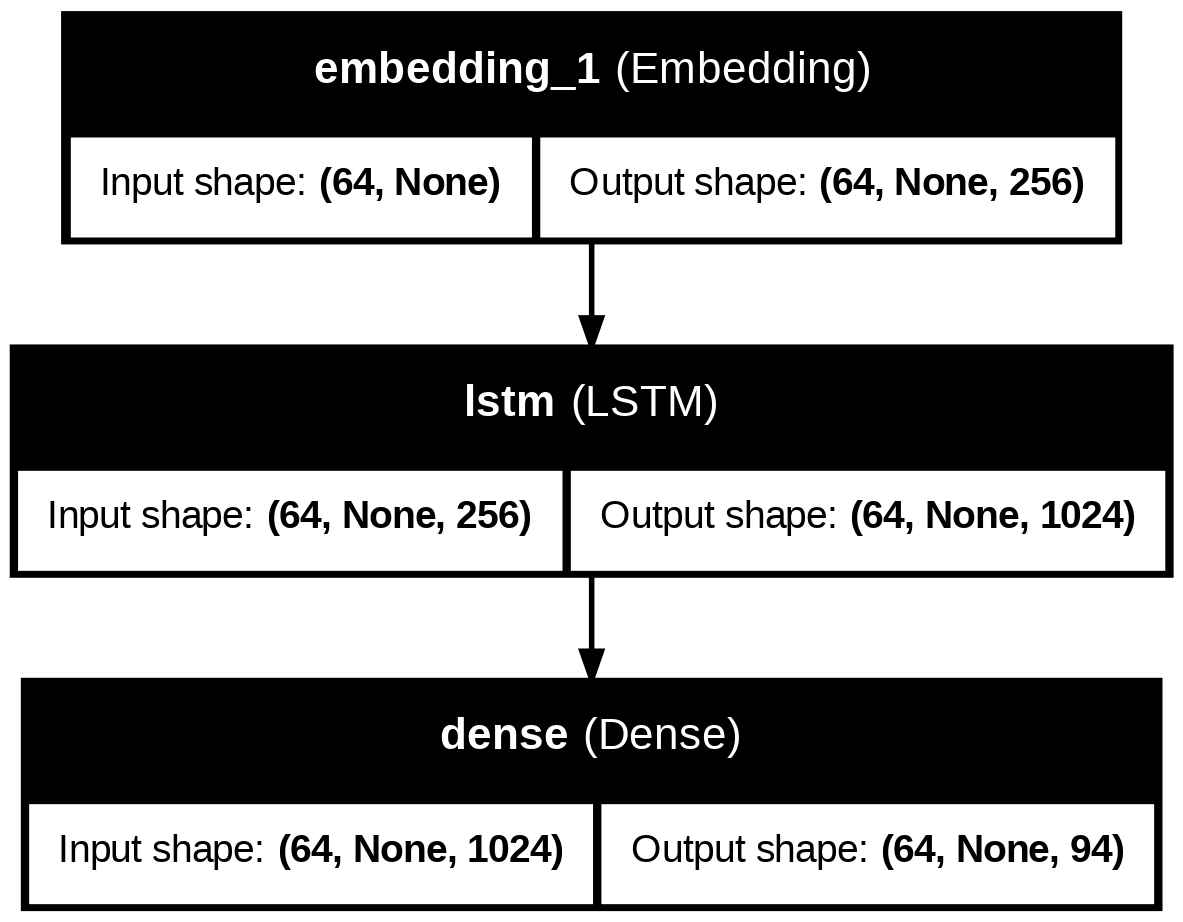

In [29]:
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
)

For each character the model looks up the embedding, runs the GRU one timestep with the embedding as input, and applies the dense layer to generate logits predicting the log-likelihood of the next character:

![Model architecture](https://www.tensorflow.org/tutorials/text/images/text_generation_training.png)

Image source: [Text generation with an RNN](https://www.tensorflow.org/tutorials/text/text_generation) notebook.

## Try the model

In [30]:
for input_example_batch, target_example_batch in dataset.take(1):
    example_batch_predictions = model(input_example_batch)
    print(example_batch_predictions.shape, "# (batch_size, sequence_length, vocab_size)")


(64, 100, 94) # (batch_size, sequence_length, vocab_size)


To get actual predictions from the model we need to sample from the output distribution, to get actual character indices. This distribution is defined by the logits over the character vocabulary.

In [31]:
print('Prediction for the 1st letter of the batch 1st sequense:')
print(example_batch_predictions[0, 0])

Prediction for the 1st letter of the batch 1st sequense:
tf.Tensor(
[-2.6471334e-04  3.8893055e-03 -6.2719849e-03 -8.5548189e-04
  1.2359180e-04  5.5628968e-03 -4.8073614e-04  1.7373502e-03
  6.3779652e-03 -2.3588014e-03  4.6249046e-03  5.6011891e-03
  2.7903658e-03 -8.7386696e-05 -1.2707509e-03 -5.8631203e-03
 -3.5233426e-04  1.7671932e-03  1.7970236e-03 -1.9831974e-03
 -4.8362836e-05 -1.0072297e-03  3.6067546e-03  2.5342177e-03
 -5.1371260e-03 -1.0125854e-03 -1.4456674e-03  2.6394213e-03
 -2.6236873e-03 -4.6902164e-03 -8.4767397e-03 -3.4173303e-03
  4.7966042e-03 -1.7298955e-03 -6.7357073e-06 -8.2216057e-04
 -1.2346770e-03 -6.1932979e-03  1.3801508e-03 -3.3988960e-03
  5.2210101e-04 -3.0563893e-03 -6.2778778e-03  4.3939115e-04
 -1.4763484e-03 -2.1848844e-03 -3.0466465e-03  1.4806469e-05
 -3.5919663e-03  4.2109951e-04 -3.8588050e-04 -2.9272071e-04
  2.8266767e-03  1.7226441e-03  9.9878386e-03 -1.7346004e-03
 -5.3511867e-03 -3.1957820e-03  2.9245412e-03  4.3834657e-03
 -1.6349951e-03  

In [32]:
# Quick overview of how tf.random.categorical() works.

# logits is 2-D Tensor with shape [batch_size, num_classes].
# Each slice [i, :] represents the unnormalized log-probabilities for all classes.
# In the example below we say that the probability for class "0" is low but the
# probability for class "2" is much higher.
tmp_logits = [
  [-0.95, 0, 0.95],
];

# Let's generate 5 samples. Each sample is a class index. Class probabilities
# are being taken into account (we expect to see more samples of class "2").
tmp_samples = tf.random.categorical(
    logits=tmp_logits,
    num_samples=5
)

print(tmp_samples)

tf.Tensor([[2 2 1 1 2]], shape=(1, 5), dtype=int64)


In [33]:
sampled_indices = tf.random.categorical(
    logits=example_batch_predictions[0],
    num_samples=1
)

sampled_indices.shape

TensorShape([100, 1])

In [34]:
sampled_indices = tf.squeeze(
    input=sampled_indices,
    axis=-1
).numpy()

sampled_indices.shape

(100,)

In [35]:
sampled_indices

array([80, 28, 55, 48, 15, 74, 39, 46, 61, 14, 55, 54, 45, 25, 64, 74, 55,
       38, 34, 89, 23, 32,  7, 13, 48,  4, 60, 70, 66, 11, 36, 86, 24, 74,
        2, 53, 69, 88, 44, 41, 41, 78, 73, 78, 92, 45, 45, 77, 81, 46,  3,
       65, 57, 68, 78, 38, 89, 58, 37,  5, 10, 66, 11, 61, 46,  3, 23, 67,
       77, 28, 45, 88, 61, 22, 23, 61, 58, 90, 69, 90, 69, 25, 70, 69,  5,
       75, 62, 22, 85, 42, 77, 18, 33, 76, 88,  9, 89,  4, 75, 92])

In [36]:
print('Input:\n', repr(''.join(index2char[input_example_batch[0]])))
print()
print('Next char prediction:\n', repr(''.join(index2char[sampled_indices])))

Input:
 'itness. Inspector\nBradstreet, B division, gave evidence as to the arrest of Horner, who\nstruggled fr'

Next char prediction:
 '½CcW2vNUi1cbT?lvcMI’:G)0W%hrn.Kœ;v!aq‘SPPzuz•TTyàU$mepzM’fL&-n.iU$:oyCT‘i9:if“q“q?rq&wj9éQy5Hx‘,’%w•'


In [37]:
for i, (input_idx, sample_idx) in enumerate(zip(input_example_batch[0][:5], sampled_indices[:5])):
    print('Prediction {:2d}'.format(i))
    print('  input: {} ({:s})'.format(input_idx, repr(index2char[input_idx])))
    print('  next predicted: {} ({:s})'.format(target_idx, repr(index2char[sample_idx])))

Prediction  0
  input: 61 (np.str_('i'))
  next predicted: 56 (np.str_('½'))
Prediction  1
  input: 72 (np.str_('t'))
  next predicted: 56 (np.str_('C'))
Prediction  2
  input: 66 (np.str_('n'))
  next predicted: 56 (np.str_('c'))
Prediction  3
  input: 57 (np.str_('e'))
  next predicted: 56 (np.str_('W'))
Prediction  4
  input: 71 (np.str_('s'))
  next predicted: 56 (np.str_('2'))


## Train the model

At this point the problem can be treated as a standard classification problem. Given the previous RNN state, and the input this time step, predict the class of the next character.

### Attach an optimizer, and a loss function

In [38]:
# An objective function.
# The function is any callable with the signature scalar_loss = fn(y_true, y_pred).
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(
      y_true=labels,
      y_pred=logits,
      from_logits=True
    )

example_batch_loss = loss(target_example_batch, example_batch_predictions)

print("Prediction shape: ", example_batch_predictions.shape, " # (batch_size, sequence_length, vocab_size)")
print("scalar_loss:      ", example_batch_loss.numpy().mean())

Prediction shape:  (64, 100, 94)  # (batch_size, sequence_length, vocab_size)
scalar_loss:       4.543536


In [39]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=adam_optimizer,
    loss=loss
)

### Configure checkpoints

In [40]:
# Directory where the checkpoints will be saved.
checkpoint_dir = 'tmp/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Name of the checkpoint files
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt_{epoch}.weights.h5')

checkpoint_callback=tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True
)

### Execute the training

In [41]:
EPOCHS=40

In [42]:
history = model.fit(
  x=dataset,
  epochs=EPOCHS,
  callbacks=[
    checkpoint_callback
  ]
)

Epoch 1/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 3.1634
Epoch 2/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 2.2813
Epoch 3/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 2.0071
Epoch 4/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 1.8254
Epoch 5/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 1.6928
Epoch 6/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 1.5992
Epoch 7/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 1.5122
Epoch 8/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 1.4523
Epoch 9/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 1.3971
Epoch 10/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 1.3530
Epoch 11/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - loss: 1.3161
Epoch 12/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 1.2843
Epoch 13/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - loss: 1.2569
Epoch 14/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 1.2282
Epoch 15/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 1.2032

In [43]:
def render_training_history(training_history):
    loss = training_history.history['loss']
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.plot(loss, label='Training set')
    plt.legend()
    plt.grid(linestyle='--', linewidth=1, alpha=0.5)
    plt.show()

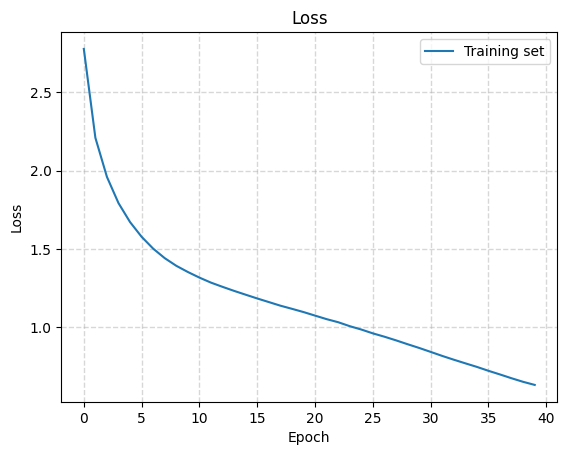

In [44]:
render_training_history(history)

## Generate text

### Restore the latest checkpoint

To keep this prediction step simple, use a batch size of 1.

Because of the way the RNN state is passed from timestep to timestep, the model only accepts a fixed batch size once built.

To run the model with a different `batch_size`, we need to rebuild the model and restore the weights from the checkpoint.

In [45]:
tf.train.latest_checkpoint(checkpoint_dir)

In [46]:
tf.train.latest_checkpoint(checkpoint_dir)
simplified_batch_size = 1

model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=1)

model.load_weights('tmp/checkpoints/ckpt_40.weights.h5')

model.build(tf.TensorShape([simplified_batch_size, None]))

In [47]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (1, None, 256)         │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (1, None, 1024)        │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, None, 94)          │        96,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,367,390 (20.47 MB)

 Trainable params: 5,367,390 (20.47 MB)

 Non-trainable params: 0 (0.00 B)

### The prediction loop

The following code block generates the text:

- It Starts by choosing a start string, initializing the RNN state and setting the number of characters to generate.

- Get the prediction distribution of the next character using the start string and the RNN state.

- Then, use a categorical distribution to calculate the index of the predicted character. Use this predicted character as our next input to the model.

- The RNN state returned by the model is fed back into the model so that it now has more context, instead than only one character. After predicting the next character, the modified RNN states are again fed back into the model, which is how it learns as it gets more context from the previously predicted characters.

![Prediction loop](https://www.tensorflow.org/tutorials/text/images/text_generation_sampling.png)

Image source: [Text generation with an RNN](https://www.tensorflow.org/tutorials/text/text_generation) notebook.

In [48]:
import glob

# Get list of all weight files
weight_files = glob.glob(os.path.join(checkpoint_dir, '*.weights.h5'))

if weight_files:
    latest = max(weight_files, key=os.path.getctime)  # or sort by name, etc.
    model.load_weights(latest)
    print(f"Loaded weights from: {latest}")
else:
    print("No weights file found. Using randomly initialized model.")

Loaded weights from: tmp/checkpoints/ckpt_40.weights.h5


In [49]:
# num_generate
# - number of characters to generate.
#
# temperature
# - Low temperatures results in more predictable text.
# - Higher temperatures results in more surprising text.
# - Experiment to find the best setting.

def generate_text(model, start_string, num_generate = 1000, temperature=1.0):
    # Evaluation step (generating text using the learned model)

    # Converting our start string to numbers (vectorizing).
    input_indices = [char2index[s] for s in start_string]
    input_indices = tf.expand_dims(input_indices, 0)

    # Empty string to store our results.
    text_generated = []

    # Here batch size == 1.
    # Reset states for RNN layers if they are stateful
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

    for char_index in range(num_generate):
        predictions = model(input_indices)
        # remove the batch dimension
        predictions = tf.squeeze(predictions, 0)

        # Using a categorical distribution to predict the character returned by the model.
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(
        predictions,
        num_samples=1
        )[-1,0].numpy()

        # We pass the predicted character as the next input to the model
        # along with the previous hidden state.
        input_indices = tf.expand_dims([predicted_id], 0)

        text_generated.append(index2char[predicted_id])

    return (start_string + ''.join(text_generated))
print(generate_text(model, start_string=u"Sherlock: "))

Sherlock: come to a hearty
death stains upon the left-severe marriage. With a tooo of-lamp a she, and yet there she followed.

“Abute so. Now let the right give me his contempletion of him or Mr.
Sherlock Holmes, I very sharped youn menom?”

“Yes, I heard a fresh gigts of hill-dressed man, and had listened her in ig.

“I beg promise to assure, Watson,” he remarked this investigation. “But we have had the
initials who threw account of it has been a sudden concident gates which struck his own state
of Mr. Aloysius Doran, as now the others,
only one wing later, you had already amarts you see to him?
Combinst that I can see that there was
behind me. But it is very essential sharplying or.”

“That’s importance, you see, but none who on waiting her the contrast how t was that? But he’
put my hand is correct have farther side was set farthing in
brainst bail it. Here one hands. Yes, for hand yet, it is
the vigorously, ‘You pay in which Mr. Jones laby to ill that Miss Sutherland—the blow
manag

In [50]:
# Generate the text with default temperature (1.0).
print(generate_text(model, start_string=u"Sherlock: "))

Sherlock: I wonder of you and quite understand that your
permission Holmes passed her sellow, and do so warmly into very head
with the fed terms of actionally tradedamily.

“I was recalled upterible d foint which Miss Hunter
hasten to answer forever hat, and I should think, that
whatever hearty he was averse to the window not providence, and they suddenly relapsed into a
grim and waited the known besidest, of course, for the colonel has been here?” I asked, ‘a manserEdict, and such a sight of a bachelor. It was my
confidential servant with a great gold wink (www.gutenberg.org/Loston came, and I could not wish anything it there.”

“But the wall, Watson,” he said, “Pareles dressed and had a passion down his
long, holder and employer, looking defined me at the famous shog and lock at
him in a sheet of secret very selfic-morning,
Mr. Holmes, that I am lying down.”

“The matter is only tryly. I am much mistaken, “that the papers has seen hungs in. In the windows of the cleary
yet words. Go 

In [ ]:
# Generate the text with higher temperature to get more unexpected results.
print(generate_text(model, start_string=u"Sherlock: ", temperature=1.5))

Sherlock: I swear it.

First Citizen:
If ey;
And that omit there's honest ll serve I, Sir Cobesenes,
Signior Lauching and no mistress, I must appear.

AUFIDIUS:
Ever followed of thy disposition.

FRIAR THOMAS:
Tell him whatever poxeex-

JULOLIO:
So 'twas much: sesu it
shall exil
Le:
In sudden, then to Cote, sisters have been, to God,
Ay, pility, any thing banishment.

TRANIO:
Minbetime unquepose and freedom as my weak.
Good night, let us not deposee well choose himself will wash
He does in vain comes full outwoward.

JULIET:
Show me this hour mother?

DUCHESS OF YOLK:
Who have the king! Would Warwick, and a queen;
but thinks a netther grief.
Your feath, my lord, wis face,
Nothing, muffle nothing spake himself.
If fair nine, the duke's not strike,
And bite your trade; I'll bear thee in your name
Is grace meane you talk of amity
Within my commission, that I have
not high, go back.
Your execution3RYORK:
Go to ime; your grace shall be hanged.
God save Vincentio topprison; other dain led me

## Explore impact of temperature

In [51]:
def evaluate_spelling_accuracy(generated_text):

    # Initialize spell checker
    spell = SpellChecker(language='en')

    # Clean the text and split into words
    cleaned_text = re.sub(r'[^\w\s]', ' ', generated_text.lower())
    words = [word for word in cleaned_text.split() if word.strip()]

    words = [word for word in words if word.isalpha() and len(word) > 1]

    # Count total words
    total_words = len(words)

    if total_words == 0:
        return {
            "correct_words": 0,
            "incorrect_words": 0,
            "total_words": 0,
            "spelling_accuracy": 0.0,
            "most_common_incorrect": []
        }

    # Find misspelled words
    misspelled = spell.unknown(words)

    # Count correct words
    correct_words = total_words - len(misspelled)

    # Calculate spelling accuracy
    spelling_accuracy = (correct_words / total_words) * 100

    # Get most common incorrect words
    incorrect_counter = Counter(misspelled)
    most_common_incorrect = incorrect_counter.most_common(10)

    # Return metrics
    return {
        "correct_words": correct_words,
        "incorrect_words": len(misspelled),
        "total_words": total_words,
        "spelling_accuracy": spelling_accuracy,
        "most_common_incorrect": most_common_incorrect
    }

In [52]:
start_string = "Sherlock Holmes looked at me with a smile. "
temperatures = [0.2, 0.5, 0.7, 1.0, 1.3, 1.7, 2.0]

for temp in temperatures:
    print(f"\n=== TEMPERATURE: {temp} ===\n")
    generated_text = generate_text(
        model,
        start_string=start_string,
        num_generate=300,
        temperature=temp
    )
    print(generated_text)


=== TEMPERATURE: 0.2 ===

Sherlock Holmes looked at me with a smile. I am sorry that I have had my groom, in the case of the matter, she suddenly shrieked out in the matter, and they suppose that they
were all three merely that I should have spoken to you in the contrary, you are no
lengthe inquest,” he shouted.

“I think that I have heard it is a very honourandy and

=== TEMPERATURE: 0.5 ===

Sherlock Holmes looked at me with a smile. I am to love him.”

“I would pay it. And yet I should have a little startled a good of whisel, and
I was shown into the richest limp and the effect that the case was in the direction of the
copper of pipe with a strong factor in the handling of Serpentine-mews,
and then only that I might put in the 

=== TEMPERATURE: 0.7 ===

Sherlock Holmes looked at me with a smile. I am very much obliged to
your room, following her keener placed beggar. And now we were to the
office is famoulation occurred to me as if a registered trademark. Of course it is a supper 

In [53]:
import re
from collections import Counter

def analyze_text(text, original_prompt_length):
    # Analyze only the generated portion
    generated_text = text[original_prompt_length:]

    # Word diversity (higher = more diverse vocabulary)
    words = re.findall(r'\b\w+\b', generated_text.lower())
    word_diversity = len(set(words)) / len(words) if words else 0

    # Repetition rate (higher = more repetition)
    word_counts = Counter(words)
    repetitions = sum(count - 1 for count in word_counts.values())
    repetition_rate = repetitions / len(words) if words else 0

    # Average sentence length
    sentences = re.split(r'[.!?]+', generated_text)
    sentences = [s for s in sentences if s.strip()]
    avg_sentence_length = sum(len(s.split()) for s in sentences) / len(sentences) if sentences else 0

    # Spelling accuracy
    spelling_accuracy = evaluate_spelling_accuracy(generated_text)['spelling_accuracy']

    return {
        "word_diversity": word_diversity,
        "repetition_rate": repetition_rate,
        "avg_sentence_length": avg_sentence_length,
        "spelling_accuracy" : spelling_accuracy
    }

results = {}
for temp in temperatures:
    # Generate 5 samples per temperature for more reliable metrics
    metrics = []
    for _ in range(5):
        text = generate_text(model, start_string, 300, temp)
        metrics.append(analyze_text(text, len(start_string)))

    # Average the metrics
    results[temp] = {k: sum(m[k] for m in metrics)/len(metrics) for k in metrics[0]}

In [54]:
# Print the results
print(f"{'Temperature':<12} {'Word Diversity':<18} {'Repetition Rate':<18} {'Avg Sentence Length':<24} {'Spelling accuracy'}")
print("-" * 100)

for temp in sorted(results):
    metrics = results[temp]
    print(f"{temp:<12} {metrics['word_diversity']:<18.3f} {metrics['repetition_rate']:<18.3f} {metrics['avg_sentence_length']:<24.3f} {metrics['spelling_accuracy']:0.2f}")


Temperature  Word Diversity     Repetition Rate    Avg Sentence Length      Spelling accuracy
----------------------------------------------------------------------------------------------------
0.2          0.719              0.281              20.150                   99.25
0.5          0.761              0.239              29.420                   97.85
0.7          0.780              0.220              17.183                   95.27
1.0          0.834              0.166              17.917                   90.64
1.3          0.841              0.159              10.143                   86.92
1.7          0.946              0.054              8.278                    66.54
2.0          0.932              0.068              6.108                    55.38


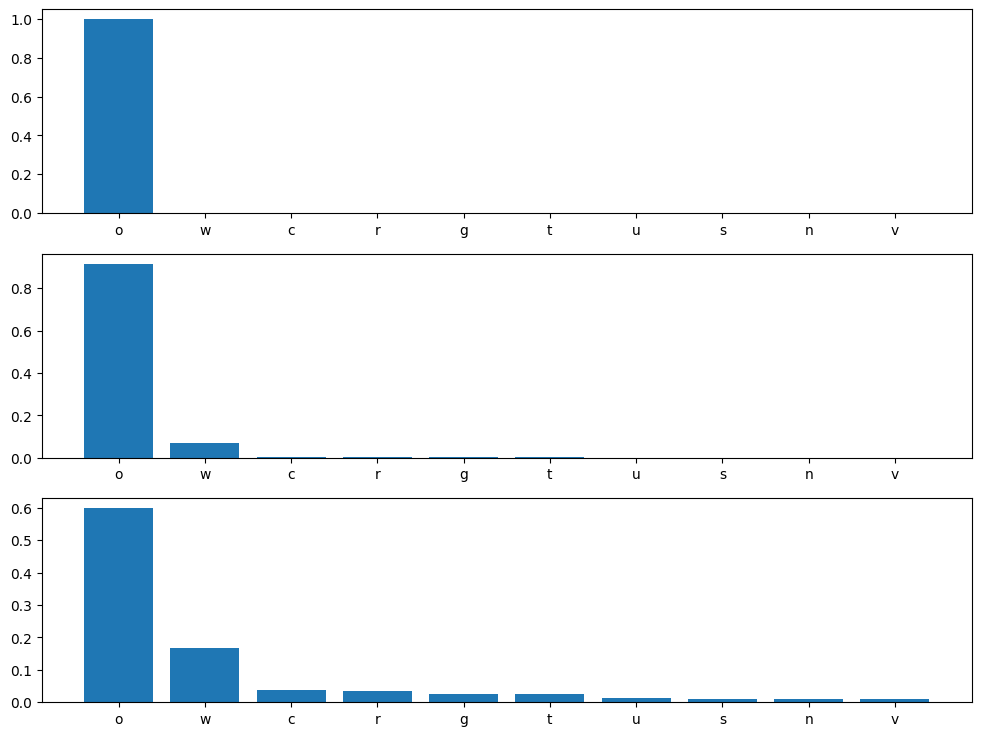

In [56]:
def visualize_next_char_distribution(model, prompt, temperatures=[0.5, 1.0, 1.5], char2index=None, index2char=None):
    """Visualize how temperature affects the probability distribution of the next character prediction."""

    # Convert prompt to input indices
    input_indices = [char2index[s] for s in prompt]
    input_indices = tf.expand_dims(input_indices, 0)  # Shape: (1, len(prompt))

    # Run the model and get the last time step's predictions
    predictions = model(input_indices)
    predictions = tf.squeeze(predictions, 0)[-1]  # Shape: (vocab_size,)

    # Compute base probabilities to determine top-k characters (for consistent x-axis)
    base_probs = tf.nn.softmax(predictions).numpy()
    top_indices = np.argsort(base_probs)[-10:][::-1]  # Top 10 indices
    top_chars = [index2char[i] for i in top_indices]

    # Create plot
    plt.figure(figsize=(12, len(temperatures) * 3))

    for i, temp in enumerate(temperatures):
        scaled_logits = predictions / temp
        scaled_probs = tf.nn.softmax(scaled_logits).numpy()

        plt.subplot(len(temperatures), 1, i + 1)
        plt.bar(top_chars, scaled_probs[top_indices])

visualize_next_char_distribution(
    model,
    "Sherlock Holmes looked at the flo",
    temperatures=[0.3, 1.0, 2.0],
    char2index=char2index,
    index2char=index2char
)


## Save the model

In [ ]:
model_name = 'text_generation_sherlock_rnn.h5'
model.save(model_name)

## Converting the model to web-format

To use this model on the web we need to convert it into the format that will be understandable by [tensorflowjs](https://www.tensorflow.org/js). To do so we may use [tfjs-converter](https://github.com/tensorflow/tfjs/tree/master/tfjs-converter) as following:

```
tensorflowjs_converter --input_format keras \
  ./experiments/text_generation_shakespeare_rnn/text_generation_shakespeare_rnn.h5 \
  ./demos/public/models/text_generation_shakespeare_rnn
```

You find this experiment in the [Demo app](https://trekhleb.github.io/machine-learning-experiments) and play around with it right in you browser to see how the model performs in real life.